In [ ]:
# Imports
import time
import csv
import random
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup

# Configuration
URL = 'https://hamrobazaar.com/category/motorcycles/EB9C8147-07C0-4951-A962-381CDB400E37/59973AED-F03D-4985-9AEC-542831929081'
OUTPUT_CSV = 'motocycle_243.csv'
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
TABS_AT_ONCE = 5  # number of tabs to open simultaneously
MAX_PRODUCTS = 500

# Setup Chrome Driver
def get_chrome_driver():
    options = Options()
    # options.add_argument('--headless')  # Turn off for debugging
    options.add_argument('--disable-gpu')
    options.add_argument(f'--user-agent={USER_AGENT}')
    options.add_argument('--start-maximized')
    driver = webdriver.Chrome(options=options)
    return driver

# Scroll to collect links
def collect_product_links(driver, url, max_links=MAX_PRODUCTS):
    driver.get(url)
    time.sleep(5)
    links = set()
    scroll_pause = 1.5
    last_height = driver.execute_script("return document.body.scrollHeight")
    scroll_attempts = 0

    print("Starting scrolling to collect product links...")

    while len(links) < max_links and scroll_attempts < 200:
        driver.execute_script("window.scrollBy(0, 400);")
        time.sleep(random.uniform(scroll_pause, scroll_pause + 0.5))
        driver.execute_script("window.scrollBy(0, -200);")
        time.sleep(random.uniform(0.5, 0.8))

        soup = BeautifulSoup(driver.page_source, 'html.parser')
        for a in soup.find_all('a', href=True):
            href = a['href']
            if '/product/' in href:
                if href.startswith('http'):
                    links.add(href)
                else:
                    links.add('https://hamrobazaar.com' + href)

        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            scroll_attempts += 1
        else:
            scroll_attempts = 0
            last_height = new_height

        if len(links) % 20 == 0:
            print(f"Links collected so far: {len(links)}")

    print(f"\nTotal product links collected: {len(links)}\n")
    return list(links)[:max_links]


# Parse product details
def parse_product(driver, url):
    driver.get(url)
    time.sleep(random.uniform(2, 3))
    soup = BeautifulSoup(driver.page_source, 'html.parser')

    def get_text(selectors):
        for sel in selectors:
            el = soup.select_one(sel)
            if el:
                return el.get_text(strip=True)
        return 'N/A'

    name = get_text(['h1', '.page--title', '.pname', '.product-title'])
    price = get_text(['.price', 'h2.price', '.product-price'])

    transmission = types = fuel = make_year = mileage = lot_no = color = km_run = engine_cc = ''
    for item in soup.select('.feature__item, .feature-item, [class*="feature"]'):
        parts = item.get_text(separator='|', strip=True).split('|')
        if len(parts) >= 2:
            label, value = parts[0].lower(), parts[1]
            if 'transmission' in label: transmission = value
            elif 'type' in label: types = value
            elif 'fuel' in label: fuel = value
            elif 'year' in label: make_year = value
            elif 'mileage' in label: mileage = value
            elif 'lot' in label: lot_no = value
            elif 'colour' in label or 'color' in label: color = value
            elif 'kilometer run' in label: km_run = value
            elif 'engine' in label or 'cc' in label: engine_cc = value

    return {
        'Name': name,
        'Price': price,
        'Transmission': transmission,
        'Types': types,
        'Fuel': fuel,
        'Make Year': make_year,
        'Mileage': mileage,
        'Lot No': lot_no,
        'Colour': color,
        'Kilometer Run': km_run,
        'Engine (CC)': engine_cc
    }


# Save data
def save_to_csv(rows, filename):
    if not rows: return
    fieldnames = ['Name', 'Price', 'Transmission', 'Types', 'Fuel', 'Make Year', 'Mileage',
                  'Lot No', 'Colour', 'Kilometer Run', 'Engine (CC)']
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} products to {filename}")


# Main function
def main():
    driver = get_chrome_driver()
    try:
        links = collect_product_links(driver, URL, MAX_PRODUCTS)
        print("Starting product scraping with multiple tabs...")

        rows = []
        for i in range(0, len(links), TABS_AT_ONCE):
            batch = links[i:i+TABS_AT_ONCE]
            tabs = []

            # Open tabs
            for j, link in enumerate(batch):
                if j == 0:
                    driver.get(link)  # first tab
                else:
                    driver.execute_script(f"window.open('{link}','_blank');")
            time.sleep(2)

            # Switch through tabs and scrape
            for k in range(len(batch)):
                driver.switch_to.window(driver.window_handles[k])
                data = parse_product(driver, driver.current_url)
                rows.append(data)
                print(f"[{i+k+1}/{len(links)}] {data['Name'][:50]} - {data['Price']}")
                time.sleep(random.uniform(1, 2.5))

            # Close extra tabs
            while len(driver.window_handles) > 1:
                driver.switch_to.window(driver.window_handles[-1])
                driver.close()
            driver.switch_to.window(driver.window_handles[0])

            # Checkpoint save
            if (i + TABS_AT_ONCE) % 25 == 0:
                save_to_csv(rows, OUTPUT_CSV)

        save_to_csv(rows, OUTPUT_CSV)

    finally:
        driver.quit()

if __name__ == '__main__':
    main()

Starting scrolling to collect product links...
Links collected so far: 20
Links collected so far: 40
Links collected so far: 60
Links collected so far: 80
Links collected so far: 100
Links collected so far: 120
Links collected so far: 140
Links collected so far: 160
Links collected so far: 180
Links collected so far: 180
Links collected so far: 200
Links collected so far: 220
Links collected so far: 240
Links collected so far: 260
Links collected so far: 280
Links collected so far: 300
Links collected so far: 320
Links collected so far: 340
Links collected so far: 360
Links collected so far: 380
Links collected so far: 380
Links collected so far: 400
Links collected so far: 420
Links collected so far: 440
Links collected so far: 460
Links collected so far: 480
Links collected so far: 500

Total product links collected: 500

Starting product scraping with multiple tabs...
[1/500] pleasure 44lot - रू. 50,000
[2/500] Honda shine 118 sale - रू. 1,58,000
[3/500] 220 pulser - रू. 3,80,000
[4

[138/500] NQi Electric Scooter - रू. 2,80,000
[139/500] Benelli 135cc 96 Lot Sale Or Exchange - रू. 1,09,000
[140/500] Gixxer 88lot - रू. 1,10,000
[141/500] Vespa vxl 106 lot - रू. 1,15,000
[142/500] Honda Shine 26 Lot - रू. 58,000
[143/500] Honda Dio 52 Fresh ✅Mint Condition - रू. 73,500
[144/500] Urgent Sell Tvs( RTR) 1604v - रू. 2,05,000
[145/500] urgent sell - रू. 125
[146/500] Yamaha 150 Fzs v3 Bs6 Fi Abs Single Hand 2024 mode - रू. 3,35,000
[147/500] vespa 003 lot - रू. 1,15,000
[148/500] grazia 008 lot - रू. 1,50,000
[149/500] Urgent sale price 160k - रू. 160
[150/500] Honda shine 39 lot sale - रू. 63,000
Saved 150 products to motocycle_243.csv
[151/500] Hornet bike ba 75 pa on sale - रू. 95,000
[152/500] Tvs raider 125 049 lot 8500 k.m clocked - रू. 2,55,000
[153/500] Crossfire Hj 250cc 135 lot 9803656430 - रू. 4,10,000
[154/500] pulsar 150 035lot - रू. 1,95,000
[155/500] Aprilla Sr125 Like New 131 Lot - रू. 1,55,000
[156/500] Honda Avator 97 Lot Sale Or Exchange - रू. 1,39,000

[286/500] Ntorq 125 Fi 2021 Last Model 133 Lot Onsell - रू. 1,98,000
[287/500] r15M 042lot single hand urgent sell - रू. 3,78,000
[288/500] aprila sr 125 019 lot - रू. 1,35,000
[289/500] Honda Shine Fully Fresh Condition Lot-57 - रू. 88,000
[290/500] suzuki gixxer 88lot - रू. 1,05,000
[291/500] suzuki gixxer 88lot - रू. 1,15,000
[292/500] FZ 250 - रू. 1,55,000
[293/500] hero super splendor 71 lot - रू. 95,000
[294/500] Suzuki Bike - रू. 45,000
[295/500] Ns 160 145 lot - रू. 1,70,000
[296/500] 220 Pulsar 2018 - रू. 2,10,000
[297/500] Hero Xoom 125 Scooter – Yellow color Latest Model - रू. 2,15,000
[298/500] Single Hand Bajaj PULSAR 220F Abs - रू. 2,38,000
[299/500] Pleasure+ Fi 142 Lot like new good condition - रू. 1,45,000
[300/500] jawa 300 118lot on sell - रू. 2,86,000
Saved 300 products to motocycle_243.csv
[301/500] Radier fesh single hand on sale - रू. 1,68,000
[302/500] Tvs Nrorque Raceediton Fi 130 Lot Sale Or Exchange - रू. 2,09,000
[303/500] xpulse 200  146 lot urgent sell - र

[437/500] Royal Enfield classic 350 (106 lot) - रू. 4,38,000
[438/500] Vespa 103 lot - रू. 1,20,000
[439/500] Fz on sale - रू. 2,45,000
[440/500] Rtr 200 4v 
002 Lot 9843645282 - रू. 1,38,000
[441/500] Bike on rent for pathao Indrive yango - रू. 750
[442/500] Fzs v2 like new 144 lot single hand 9803656430 - रू. 2,65,000
[443/500] Ntorq 125 Fi 2021 Last Model 133 Lot Onsell - रू. 1,98,000
[444/500] Aprillia 150 Race edition 98 lot fixp - रू. 1,15,000
[445/500] Xpulse on sale - रू. 1,65,000
[446/500] fascino 95lot - रू. 75,000
[447/500] Bajaj pulsar - रू. 1,50,000
[448/500] gixer 88 lot 2017 model - रू. 1,12,000
[449/500] Fz V3 fresh condition 9862222784 - रू. 1,75,000
[450/500] Tvs Nrorque Raceediton 136 Lot Sale Or Exchange - रू. 2,09,000
Saved 450 products to motocycle_243.csv
[451/500] Honda Avator 135 Lot Sale Or Exchange - रू. 1,75,000
[452/500] Himalayan 450 On Sale (9k Km) - रू. 9,00,000
[453/500] Ns 200 Fully fresh 73 lot 9803656430 - रू. 1,20,000
[454/500] Gixxer 88 Lot - रू. 1

In [166]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('motocycle_243.csv')

In [167]:
df.columns

Index(['Name', 'Price', 'Transmission', 'Types', 'Fuel', 'Make Year',
       'Mileage', 'Lot No', 'Colour', 'Kilometer Run', 'Engine (CC)'],
      dtype='object')

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           499 non-null    object
 1   Price          500 non-null    object
 2   Transmission   499 non-null    object
 3   Types          499 non-null    object
 4   Fuel           499 non-null    object
 5   Make Year      499 non-null    object
 6   Mileage        258 non-null    object
 7   Lot No         260 non-null    object
 8   Colour         229 non-null    object
 9   Kilometer Run  263 non-null    object
 10  Engine (CC)    327 non-null    object
dtypes: object(11)
memory usage: 43.1+ KB


In [169]:
df[df["Name"].isnull()]

,Name,Price,Transmission,Types,Fuel,Make Year,Mileage,Lot No,Colour,Kilometer Run,Engine (CC)
348,NaN,रु,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [170]:
df=df.drop(348)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           499 non-null    object
 1   Price          499 non-null    object
 2   Transmission   499 non-null    object
 3   Types          499 non-null    object
 4   Fuel           499 non-null    object
 5   Make Year      499 non-null    object
 6   Mileage        258 non-null    object
 7   Lot No         260 non-null    object
 8   Colour         229 non-null    object
 9   Kilometer Run  263 non-null    object
 10  Engine (CC)    327 non-null    object
dtypes: object(11)
memory usage: 46.8+ KB


In [172]:
df.isnull().sum()

Name               0
Price              0
Transmission       0
Types              0
Fuel               0
Make Year          0
Mileage          241
Lot No           239
Colour           270
Kilometer Run    236
Engine (CC)      172
dtype: int64

In [173]:
df['Mileage'].value_counts()

Mileage
45                   54
35                   44
40                   36
50                   26
30                   20
55                   13
38                    7
25                    7
35+                   5
45+                   5
32                    3
50+                   3
22                    2
47                    2
42                    2
45++                  2
30+                   1
45-50                 1
40+                   1
Average               1
45-50kmpl             1
35 +                  1
18                    1
50Km/liter            1
65                    1
35-40km               1
50kmpl                1
Around 35–40 km/l     1
100                   1
40 - 45               1
25-35                 1
62 KM/Ltr             1
35-40                 1
24-29                 1
80                    1
49                    1
50kms+                1
30 35                 1
20                    1
40++                  1
37                    1
36      

In [21]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output_for_motocycle_data.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 21.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [174]:
df.drop_duplicates(inplace=True)

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           480 non-null    object
 1   Price          480 non-null    object
 2   Transmission   480 non-null    object
 3   Types          480 non-null    object
 4   Fuel           480 non-null    object
 5   Make Year      480 non-null    object
 6   Mileage        258 non-null    object
 7   Lot No         260 non-null    object
 8   Colour         229 non-null    object
 9   Kilometer Run  262 non-null    object
 10  Engine (CC)    326 non-null    object
dtypes: object(11)
memory usage: 45.0+ KB


In [176]:
df['Mileage'].unique()

array([nan, '40', '55', '35+', '35', '38', '36', '37', '50+', '50', '45',
       '30', '40++', '22', '20', '25', '45+', '30 35', '50kms+', '49',
       '47', '80', 'Around 35–40 km/l', '24-29', '35-40', '62 KM/Ltr',
       '25-35', '40 - 45', '100', '45-50', '32', '35-40km', '45++', '65',
       '42', '18', '35 +', '45-50kmpl', 'Average', '50kmpl', '30+', '40+',
       '50Km/liter', '40+ (guarantee)'], dtype=object)

In [177]:
df['Mileage'] = df['Mileage'].astype(str).str.lower().str.strip()

In [178]:
def clean_mileage(val):
    val_str = str(val).lower().strip()
    
    # Treat obvious missing/non-numeric values as NaN
    if val_str in ['nan', 'n/a', 'good']:
        return np.nan
    
    # Remove units and extra text
    val_str = val_str.replace('km/l', '').replace('kmpl', '').replace('km/ltr', '')
    val_str = val_str.replace('km per liter', '').replace('km/he', '').replace('in city', '')
    val_str = val_str.replace('per full charge', '').replace('+', '')
    
    # Normalize ranges
    val_str = val_str.replace('to', '-').replace('/', '-')
    
    # Extract numbers
    nums = re.findall(r'\d+\.?\d*', val_str)
    if len(nums) == 0:
        return np.nan
    
    nums = [float(x) for x in nums]
    return np.mean(nums)  # Average if multiple numbers (like ranges)

In [179]:
import re
df['Mileage_Clean'] = df['Mileage'].apply(clean_mileage)

In [180]:
# Fill NaN values with median
median_mileage = df['Mileage_Clean'].median()
df['Mileage_Clean'] = df['Mileage_Clean'].fillna(median_mileage)

In [181]:
df['Mileage_Clean'].unique()

array([ 40. ,  55. ,  35. ,  38. ,  36. ,  37. ,  50. ,  45. ,  30. ,
        22. ,  20. ,  25. ,  32.5,  49. ,  47. ,  80. ,  37.5,  26.5,
        62. ,  42.5, 100. ,  47.5,  32. ,  65. ,  42. ,  18. ])

In [182]:
df['Mileage_Clean'] = df['Mileage_Clean'].astype(int)

In [183]:
df.drop(columns=['MIleage_Clean','MIleage_Clean'],inplace=True)

KeyError: "['MIleage_Clean', 'MIleage_Clean'] not found in axis"

In [184]:
df.drop(columns=['Mileage'],inplace=True)

In [185]:
df

,Name,Price,Transmission,Types,Fuel,Make Year,Lot No,Colour,Kilometer Run,Engine (CC),Mileage_Clean
0,pleasure 44lot,"रू. 50,000",Manual,Scooty,Petrol,2012,NaN,NaN,NaN,NaN,40
1,Honda shine 118 sale,"रू. 1,58,000",Automatic,Standard,Petrol,2020,118,Black,19000,125,40
2,220 pulser,"रू. 3,80,000",Automatic,Sport,Petrol,2025,NaN,Red and black,5000,220,40
3,pulsar 220 055lot,"रू. 3,75,000",Automatic,Standard,Petrol,2025,NaN,NaN,NaN,NaN,40
4,Tvs Ntorque Racexp 151 Lot Sale Or Exchange,"रू. 2,75,000",Manual,Scooty,Petrol,2024,151,Red,7000,125,55
...,...,...,...,...,...,...,...,...,...,...,...
494,Hero Xtreme sports,"रू. 1,05,000",Manual,Standard,Petrol,2015,67,NaN,50k+,NaN,40
495,140 lot fzs v3 urgent sell bs6,"रू. 2,60,000",Manual,Standard,Petrol,2022,140,NaN,16000,150,45
497,Honda Dio 54 lot,"रू. 80,000",Automatic,Scooty,Petrol,2012,54,Grey,47005,109,50
498,"honda dio scooter on sale, 2021 model , 981872...","रू. 1,74,999",Automatic,Scooty,Petrol,2021,125,red grey,18000,110,38


In [186]:
df['Lot No'].unique()

array([nan, '118', '151', '125', '045', '72', '123', '90', '98', '0019',
       '52', '106', '135', '039', '111', '010', '128', '99', '146', '058',
       '119', '71', '038', '121', '006', '74', '80', '22', '42', '017',
       '027', '109', '61', '101', '107', '92', '103', '026', '040', '97',
       '16', '108', '033', '155', '94', '104', '028', '114', '73', '31',
       '102', '129', '132', '014', '96', '051', '018', '39', 'ba 75 pa',
       '049', '131', '12', '120', '009', '021', '95', '139', '148', '65',
       '042', '031', '056', '110', '144', '30', '60', '124', '112', '030',
       '37', '81', '020 Pa 7750', '76', '93', '33', '36', '24', '137',
       '044', '029', '68', '43', '59', '062', '141', '66', '89', '025',
       '126', '036', '79', '88', '156', '013', '54', '02 36 pa 0073',
       '145', '0 13 pa', '060', '142', '130', '26', '87', '054', '117',
       '46', '69', '67', '050', '3015', '011', '41', '82', '113', '147',
       '77', '048', '53', '85', '150', '160', '70', '

In [187]:
import re

def clean_lot_no(x):
    if pd.isna(x):
        return None
    # remove all alphabets and spaces
    x = re.sub(r'[^0-9]', '', str(x))
    # if result becomes empty, return None
    return int(x) if x.isdigit() else None


In [188]:
df['Lot No'] = df['Lot No'].apply(clean_lot_no)

In [189]:
median_value = df['Lot No'].median()
df['Lot No'] = df['Lot No'].replace(np.nan, median_value)

In [190]:
df['Lot No'].value_counts()

Lot No
86.0     220
135.0      5
80.0       5
54.0       5
102.0      5
        ... 
10.0       1
56.0       1
148.0      1
139.0      1
140.0      1
Name: count, Length: 134, dtype: int64

In [191]:
df["Engine (CC)"].unique()

array([nan, '125', '220', '400', '350', '110', '200', '150', '250', '160',
       '190', '302', '109', '100', '155', '113', '102', '115', '135',
       '350 cc', '334', '249', '411', '102.00cc', '150cc', '126', '199.5',
       '300', '149.5', '125CC', '149', '125cc'], dtype=object)

In [192]:
df['Engine (CC)'] = df['Engine (CC)'].astype(str).str.lower().str.strip()

In [193]:
def clean_engine(val):
    val_str = str(val).lower().strip()
    
    # Handle missing / invalid
    if val_str in ['nan', 'n/a', '0', '4', '30kw battery', '100kw', '110 kw', '87 kw']:
        return np.nan
    
    # Remove 'cc' or spaces
    val_str = val_str.replace('cc', '').replace(' ', '').replace('CC', '')
    
    # Convert liters to cc if present
    # e.g. '1.8' liters  to 1800 cc
    if re.match(r'^\d+\.?\d*$', val_str):
        num = float(val_str)
        # If plausible liters (<10), convert to cc
        if num < 10:
            return int(num * 1000)
        else:
            return int(num)
    
    # Extract any numbers in string
    nums = re.findall(r'\d+\.?\d*', val_str)
    if len(nums) == 0:
        return np.nan
    return int(float(nums[0]))

In [194]:
df['Engine_Clean'] = df['Engine (CC)'].apply(clean_engine)

In [195]:
median_engine = df['Engine_Clean'].median()
df['Engine_Clean'] = df['Engine_Clean'].fillna(median_engine)

In [196]:
df['Engine_Clean']=df['Engine_Clean'].astype(int)

In [197]:
df

,Name,Price,Transmission,Types,Fuel,Make Year,Lot No,Colour,Kilometer Run,Engine (CC),Mileage_Clean,Engine_Clean
0,pleasure 44lot,"रू. 50,000",Manual,Scooty,Petrol,2012,86.0,NaN,NaN,nan,40,150
1,Honda shine 118 sale,"रू. 1,58,000",Automatic,Standard,Petrol,2020,118.0,Black,19000,125,40,125
2,220 pulser,"रू. 3,80,000",Automatic,Sport,Petrol,2025,86.0,Red and black,5000,220,40,220
3,pulsar 220 055lot,"रू. 3,75,000",Automatic,Standard,Petrol,2025,86.0,NaN,NaN,nan,40,150
4,Tvs Ntorque Racexp 151 Lot Sale Or Exchange,"रू. 2,75,000",Manual,Scooty,Petrol,2024,151.0,Red,7000,125,55,125
...,...,...,...,...,...,...,...,...,...,...,...,...
494,Hero Xtreme sports,"रू. 1,05,000",Manual,Standard,Petrol,2015,67.0,NaN,50k+,nan,40,150
495,140 lot fzs v3 urgent sell bs6,"रू. 2,60,000",Manual,Standard,Petrol,2022,140.0,NaN,16000,150,45,150
497,Honda Dio 54 lot,"रू. 80,000",Automatic,Scooty,Petrol,2012,54.0,Grey,47005,109,50,109
498,"honda dio scooter on sale, 2021 model , 981872...","रू. 1,74,999",Automatic,Scooty,Petrol,2021,125.0,red grey,18000,110,38,110


In [198]:
df['Kilometer Run'].unique()

array([nan, '19000', '5000', '7000', '45k', '16000', '22000', '60000',
       '15000', '32000', '8500', '12300', '1212', '25000', '44k', '27000',
       '37000', '13000', '2400', '19200', '33000', '31000', '36000',
       '37635', '72000', '9000', '23000', '50 plus', '30976', '40000',
       '21000', '52000', '12000', '10400', '28000', '30', '35000',
       '27777', '39677', '45500', '36800', '4000', '45', '30000', '10000',
       '11000', '50k', '42000', '64000', '2000', '50000', '16000-19000',
       '38000', '41000', '18000', '24000', '25410', '6000', '15210',
       '4700', '20k', '24700', '20000', '34000', '41K', '27k', '32086',
       '47000', '8000', '48000', '16500', '4600', '66k', '39100', '71000',
       '3400', '3800', '40k', '13500', '1000', '38k', '46000', '30k',
       '5700', '14210', '17000', '35500', '800', '10k', '40400', '45000',
       '92000', '14000', '18313', '39000k', '33808', '2800', '19855',
       '216220', '3950', '58000', '00', '70k', '29000', '6828', '100k

In [199]:
# Replace known invalid strings with NaN
df['Kilometer Run'] = df['Kilometer Run'].replace(['-', 'nan', 'N/A', '', '0','NaN'], np.nan)

In [200]:
def clean_kmrun(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().replace("+", "")  # remove + and lowercase
    # handle 'k' as thousand
    if "k" in x:
        x = x.replace("k", "")
        return float(x) * 1000
    # remove any non-digit characters
    x = re.sub(r'[^0-9]', '', x)
    return float(x) if x else np.nandf['Kilometer Run'].astype(float)

In [201]:
df['Kilometer Run'] = df['Kilometer Run'].apply(clean_kmrun)

In [202]:
df['Kilometer Run'].unique()

array([         nan, 1.900000e+04, 5.000000e+03, 7.000000e+03,
       4.500000e+04, 1.600000e+04, 2.200000e+04, 6.000000e+04,
       1.500000e+04, 3.200000e+04, 8.500000e+03, 1.230000e+04,
       1.212000e+03, 2.500000e+04, 4.400000e+04, 2.700000e+04,
       3.700000e+04, 1.300000e+04, 2.400000e+03, 1.920000e+04,
       3.300000e+04, 3.100000e+04, 3.600000e+04, 3.763500e+04,
       7.200000e+04, 9.000000e+03, 2.300000e+04, 5.000000e+01,
       3.097600e+04, 4.000000e+04, 2.100000e+04, 5.200000e+04,
       1.200000e+04, 1.040000e+04, 2.800000e+04, 3.000000e+01,
       3.500000e+04, 2.777700e+04, 3.967700e+04, 4.550000e+04,
       3.680000e+04, 4.000000e+03, 4.500000e+01, 3.000000e+04,
       1.000000e+04, 1.100000e+04, 5.000000e+04, 4.200000e+04,
       6.400000e+04, 2.000000e+03, 1.600019e+09, 3.800000e+04,
       4.100000e+04, 1.800000e+04, 2.400000e+04, 2.541000e+04,
       6.000000e+03, 1.521000e+04, 4.700000e+03, 2.000000e+04,
       2.470000e+04, 3.400000e+04, 3.208600e+04, 4.7000

In [203]:
median_value = df['Kilometer Run'].median()
df['Kilometer Run'] = df['Kilometer Run'].fillna(median_value)

In [204]:
df.isnull().sum()

Name               0
Price              0
Transmission       0
Types              0
Fuel               0
Make Year          0
Lot No             0
Colour           251
Kilometer Run      0
Engine (CC)        0
Mileage_Clean      0
Engine_Clean       0
dtype: int64

In [205]:
df['Colour'].unique()

array([nan, 'Black', 'Red and black', 'Red', 'Blue and white', 'Grey',
       'Green', 'Navy', 'Blue', 'Red and white', 'white -red', 'blacko',
       'yellow', 'Black blue', 'green', 'black', 'blue', 'Silver gray',
       'Blue street rally', 'Neon', 'orange', 'White and black',
       'Navy blue', 'White', 'Orange', 'Blue and black', 'red',
       'red and black', 'red black', 'read', 'Graee', 'balck', 'Maroon',
       'red& black', 'Dapper black', 'Ice White', 'Red and Black',
       'Silver', 'Matte black', 'ballistic blue', 'Snow white', 'Sky',
       'Black and White', 'Royal Blue', 'black/orange', 'Navyblue',
       'Black and Gray', 'Black matte', 'black and red', 'SILVER MATT',
       'Yellow', 'Blue black', 'black, red', 'Halycon green',
       'Blue & Black', 'Dark grey', 'black and gray', 'Marid Blue',
       'white Black', 'grey', 'Red n white', 'Blue white', 'Black red',
       'Racing Blue', 'blk', 'Orginal/Black', 'Orange and white',
       'SILVER', 'Mustard yellow', '

In [ ]:
import pandas as pd
import numpy as np
import re

def clean_color(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    x = re.sub(r'[^a-z\s]', '', x)  # remove symbols and numbers
    x = re.sub(r'\s+', ' ', x).strip()  # remove extra spaces
    return x

In [207]:
df['Color'] = df['Colour'].apply(clean_color)

In [209]:
df.remove(columns=['Colour'])

AttributeError: 'DataFrame' object has no attribute 'remove'

In [ ]:
color_map = {
    'black': 'Black',
    'blk': 'Black',
    'balck': 'Black',
    'blacko': 'Black',
    'dapper black': 'Black',
    'matte black': 'Black',
    'black matte': 'Black',
    'red': 'Red',
    'read': 'Red',
    'red black': 'Red',        # if you want primary color only
    'red and black': 'Red',
    'red & black': 'Red',
    'red n white': 'Red',
    'white': 'White',
    'ice white': 'White',
    'snow white': 'White',
    'grey': 'Grey',
    'gray': 'Grey',
    'dark grey': 'Grey',
    'new grey': 'Grey',
    'blue': 'Blue',
    'navy': 'Blue',
    'navy blue': 'Blue',
    'royal blue': 'Blue',
    'blue black': 'Blue',
    'blue street rally': 'Blue',
    'blue midnight blue': 'Blue',
    'ballistic blue': 'Blue',
    'orange': 'Orange',
    'yellow': 'Yellow',
    'mustard yellow': 'Yellow',
    'green': 'Green',
    'halycon green': 'Green',
    'ocean green': 'Green',
    'army color': 'Green',
    'violet': 'Violet',
    'maroon': 'Maroon',
    'silver': 'Silver',
    'silver gray': 'Silver',
    'silver matt': 'Silver',
}

In [211]:
df['Color'] = df['Color'].map(color_map).fillna('Other')

In [212]:
df.drop(columns=['Colour','Engine (CC)'],inplace=True)

In [213]:
import re
def clean_price(x):
    if pd.isna(x):
        return np.nan
    # remove everything except digits and space
    x = re.sub(r'[^0-9\s]', '', str(x))
    # split by spaces (in case of multiple numbers)
    parts = x.split()
    # convert to integers
    nums = [int(p) for p in parts if p.isdigit()]
    # take median if multiple numbers, else single number
    if nums:
        return np.median(nums)
    else:
        return np.nan


In [214]:
df['Price'] = df['Price'].apply(clean_price)

In [215]:
df[['Price','Lot No']]=df[['Price','Lot No']].astype(int)

In [216]:
df['Kilometer Run']=df['Kilometer Run'].astype(int)

In [217]:
df.Name.unique()

array(['pleasure 44lot', 'Honda shine 118 sale', '220 pulser',
       'pulsar 220 055lot', 'Tvs Ntorque Racexp 151 Lot Sale Or Exchange',
       'dominar 023lot', 'Scooter for sale',
       'super splinter 56 lot super fresh condition on',
       'Royal Enfield Bullet Hunter 350 (045)lot',
       'Honda Aviator (72 lot)', 'pulser150 035 lot',
       'ns 200 123 lot on sale', 'Apache 200 Lot 90',
       'Honda Hornet 101 Lot Super Fresh Condition Onsell',
       'Glamour Fi System Fully Brand New Lot-036',
       'pulsar150 - 010 lot 2016 model ‼️', 'Italjet Buccaneer 250',
       'Hero Duet scooter fresh on sale',
       '0019 Lot ko Fzs V3 On sale n Exchange service',
       'Hero Xpulse 200 4v', 'Dirt Bike on sale (Runner Hawk 200cc)',
       'aprilla 150 great condition genuine 16k running', 'Honda Dio',
       'hero maestro 98lot', 'bullet parts for sale',
       'Pulsar220 Like New 111 Lot', 'Storm aprilla 010 lot on sale',
       'ntorq 125cc Fi 133 lot super fresh condition onse

In [ ]:
brands = [
    'Honda', 'Yamaha', 'TVS', 'Suzuki', 'Royal Enfield', 'Bajaj', 'KTM',
    'Hero', 'Italjet', 'Aprilia', 'Benelli', 'Jawa', 'Duke', 'CF Moto',
    'Itallica', 'Dominar', 'Xpulse', 'Rx', 'FZ', 'FZS'
]

In [219]:
def extract_brand(text):
    if pd.isna(text):
        return None
    text = str(text).lower()
    for brand in brands:
        if brand.lower() in text:
            return brand
    return 'Other'  # if no known brand is found

In [220]:
df['Brand'] = df['Name'].apply(extract_brand)

In [221]:
df['Brand'].unique()

array(['Other', 'Honda', 'TVS', 'Dominar', 'Royal Enfield', 'Italjet',
       'Hero', 'FZ', 'Suzuki', 'Xpulse', 'Yamaha', 'Benelli', 'Bajaj',
       'Duke', 'Jawa', 'Itallica', 'KTM', 'Aprilia', 'CF Moto', 'Rx'],
      dtype=object)

In [222]:
df.drop(columns=['Name'],inplace=True)

In [223]:
df['Brand'].unique()

array(['Other', 'Honda', 'TVS', 'Dominar', 'Royal Enfield', 'Italjet',
       'Hero', 'FZ', 'Suzuki', 'Xpulse', 'Yamaha', 'Benelli', 'Bajaj',
       'Duke', 'Jawa', 'Itallica', 'KTM', 'Aprilia', 'CF Moto', 'Rx'],
      dtype=object)

In [224]:
df['Make Year'].value_counts()

Make Year
2021               75
2019               51
2018               42
2022               41
2017               40
2016               38
2020               36
2015               22
2024               21
2025               18
2014               16
2012               14
2023               13
2010                8
2013                8
2008                4
2021 last           3
2009                3
0                   3
2018 last           2
2022 last           2
2006                2
2011                2
2019 last           2
22                  1
2079                1
2023 last           1
2065                1
2082                1
2024 AD             1
2001                1
1997                1
2003                1
202”                1
000                 1
Lucky Number 07     1
1998                1
19                  1
Name: count, dtype: int64

In [225]:
def clean_year(x):
    x = str(x).strip()  # remove spaces
    # Extract first 4-digit number
    match = re.search(r'\b(19\d{2}|20\d{2}|21\d{2})\b', x)
    if match:
        return int(match.group(0))
    # Extract 2-digit year (assume 2000s)
    match2 = re.search(r'\b(\d{2})\b', x)
    if match2:
        year = int(match2.group(0))
        if year <= 25:  # assume 2000-2025
            return 2000 + year
        else:  # fallback for old 2-digit years
            return 1900 + year
    return np.nan  # if no valid year found

In [226]:
df['Make Year'] = df['Make Year'].apply(clean_year)

In [227]:
df['Make Year'].unique()

array([2012., 2020., 2025., 2024., 2021., 2014., 2023., 2015., 2022.,
       2019., 2018., 2016., 2017.,   nan, 2011., 2008., 2013., 2001.,
       2010., 1998., 2006., 2009., 2007., 2003., 1997., 2082., 2065.,
       2079.])

In [228]:
df['Make Year'] = np.where(df['Make Year'].isna(), np.median(df['Make Year']), df['Make Year'])

In [ ]:
df['Make Year'].unique()

array([2012., 2020., 2025., 2024., 2021., 2014., 2023., 2015., 2022.,
       2019., 2018., 2016., 2017.,   nan, 2011., 2008., 2013., 2001.,
       2010., 1998., 2006., 2009., 2007., 2003., 1997., 2082., 2065.,
       2079.])

In [230]:
median_year = df['Make Year'].median()
df['Make Year'] = df['Make Year'].fillna(median_year)

In [231]:
df['Make Year'].unique()

array([2012., 2020., 2025., 2024., 2021., 2014., 2023., 2015., 2022.,
       2019., 2018., 2016., 2017., 2011., 2008., 2013., 2001., 2010.,
       1998., 2006., 2009., 2007., 2003., 1997., 2082., 2065., 2079.])

In [232]:
df['Make Year']=df['Make Year'].astype(int)

In [233]:
df.rename(columns={'Engine_Clean':'Engine (CC)'},inplace=True)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Price          480 non-null    int32 
 1   Transmission   480 non-null    object
 2   Types          480 non-null    object
 3   Fuel           480 non-null    object
 4   Make Year      480 non-null    int32 
 5   Lot No         480 non-null    int32 
 6   Kilometer Run  480 non-null    int32 
 7   Mileage_Clean  480 non-null    int32 
 8   Engine (CC)    480 non-null    int32 
 9   Color          480 non-null    object
 10  Brand          480 non-null    object
dtypes: int32(6), object(5)
memory usage: 33.8+ KB


In [235]:
df['Transmission'].value_counts()

Transmission
Manual       306
Automatic    174
Name: count, dtype: int64

In [239]:
df['Kilometer Run'].unique()

array([     23000,      19000,       5000,       7000,      45000,
            16000,      22000,      60000,      15000,      32000,
             8500,      12300,       1212,      25000,      44000,
            27000,      37000,      13000,       2400,      19200,
            33000,      31000,      36000,      37635,      72000,
             9000,         50,      30976,      40000,      21000,
            52000,      12000,      10400,      28000,         30,
            35000,      27777,      39677,      45500,      36800,
             4000,         45,      30000,      10000,      11000,
            50000,      42000,      64000,       2000, 1600019000,
            38000,      41000,      18000,      24000,      25410,
             6000,      15210,       4700,      20000,      24700,
            34000,      32086,      47000,       8000,      48000,
            16500,       4600,      66000,      39100,      71000,
             3400,       3800,      13500,       1000,      46

In [242]:
df.rename(columns={'Mileage_Clean':'Mileage (Km/L)'},inplace=True)

In [250]:
motor_df = df.copy()

In [251]:
motor_df.to_csv('eda_motor.csv')

In [253]:
motor_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           480 non-null    int32 
 1   Transmission    480 non-null    object
 2   Types           480 non-null    object
 3   Fuel            480 non-null    object
 4   Make Year       480 non-null    int32 
 5   Lot No          480 non-null    int32 
 6   Kilometer Run   480 non-null    int32 
 7   Mileage (Km/L)  480 non-null    int32 
 8   Engine (CC)     480 non-null    int32 
 9   Color           480 non-null    object
 10  Brand           480 non-null    object
dtypes: int32(6), object(5)
memory usage: 33.8+ KB


# EDA
## Univariate Analysis

In [255]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,480.0,1.891496e+05,2.119768e+05,0.0,100000.0,152500.0,230000.00,3.999999e+06
Make Year,480.0,2.018871e+03,6.072284e+00,1997.0,2016.0,2019.0,2021.00,2.082000e+03
Lot No,480.0,5.439815e+03,1.081145e+05,6.0,80.0,86.0,92.25,2.360073e+06
Kilometer Run,480.0,3.439030e+06,7.304738e+07,0.0,22000.0,23000.0,25000.00,1.600019e+09
Mileage (Km/L),480.0,4.058542e+01,6.648418e+00,18.0,40.0,40.0,40.00,1.000000e+02
Engine (CC),480.0,1.655583e+02,5.747938e+01,100.0,125.0,150.0,160.00,4.110000e+02


In [256]:
df.isnull().sum()

Price             0
Transmission      0
Types             0
Fuel              0
Make Year         0
Lot No            0
Kilometer Run     0
Mileage (Km/L)    0
Engine (CC)       0
Color             0
Brand             0
dtype: int64

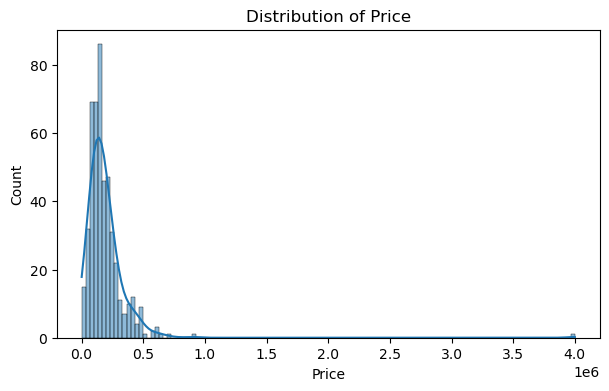

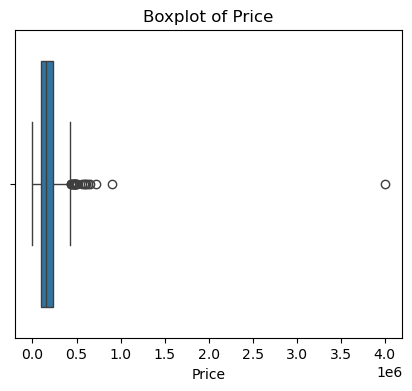

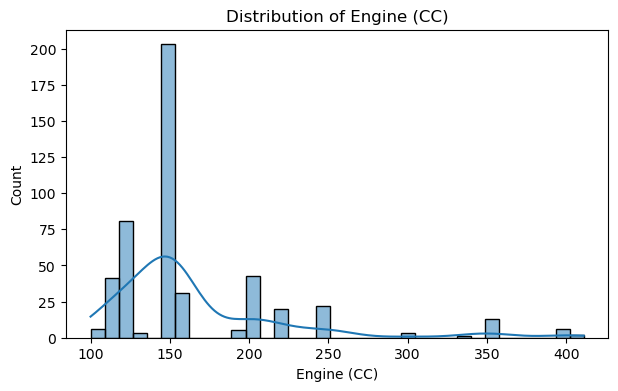

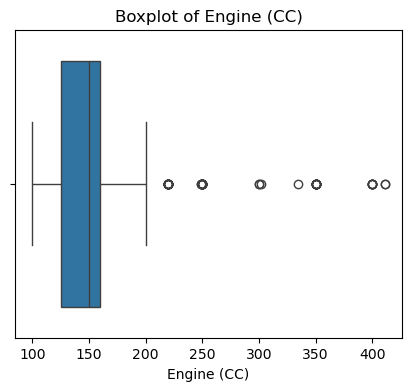

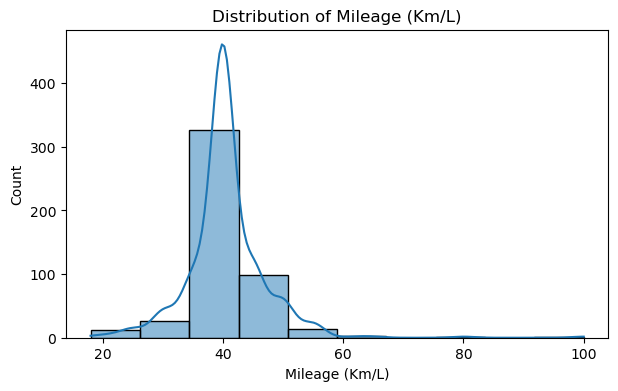

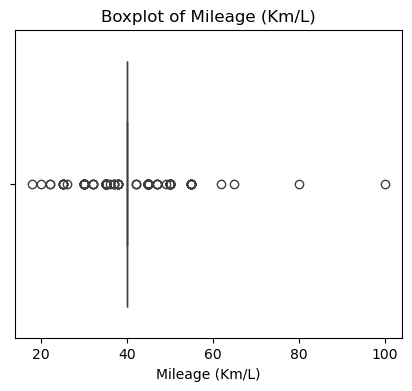

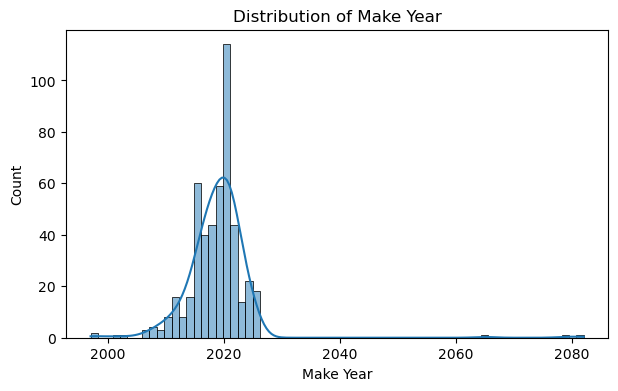

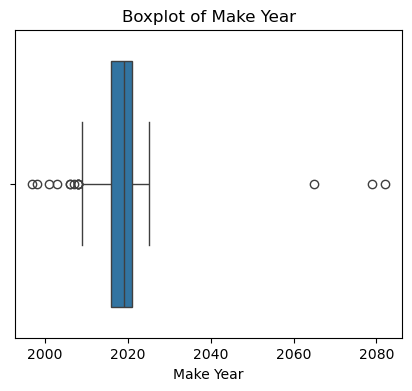

In [ ]:
# Numerical Columns
num_cols = ['Price','Engine (CC)','Mileage (Km/L)','Make Year']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [262]:
# Cat Columns

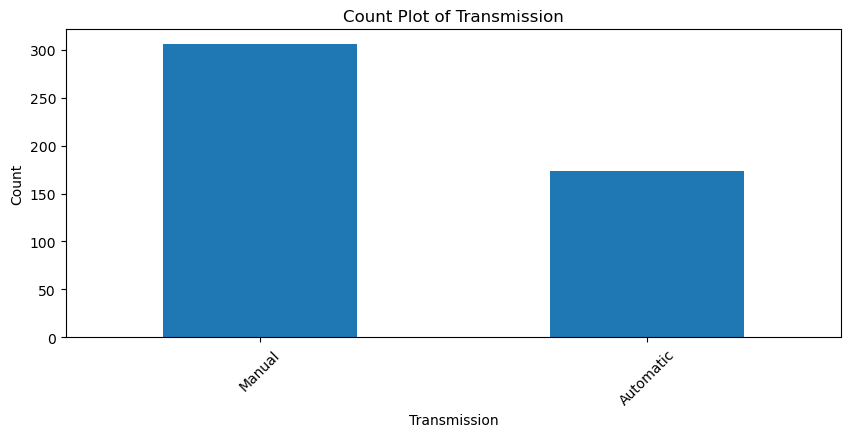

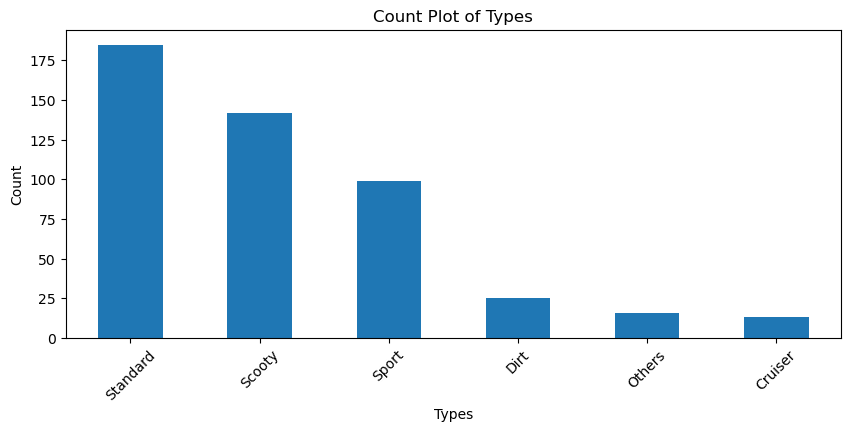

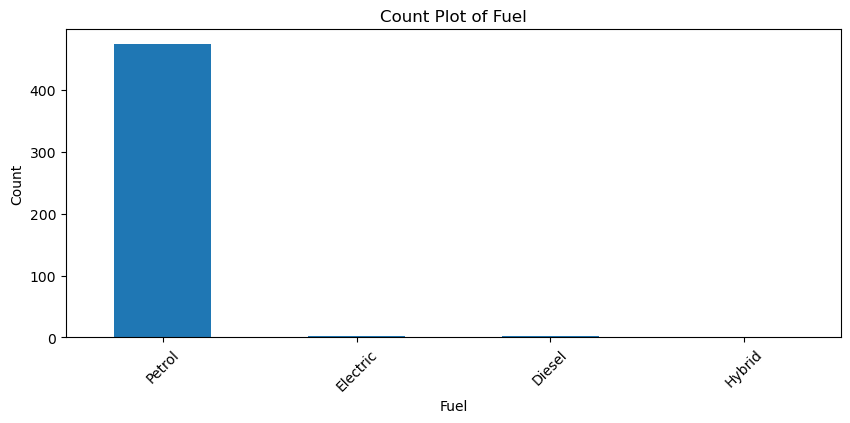

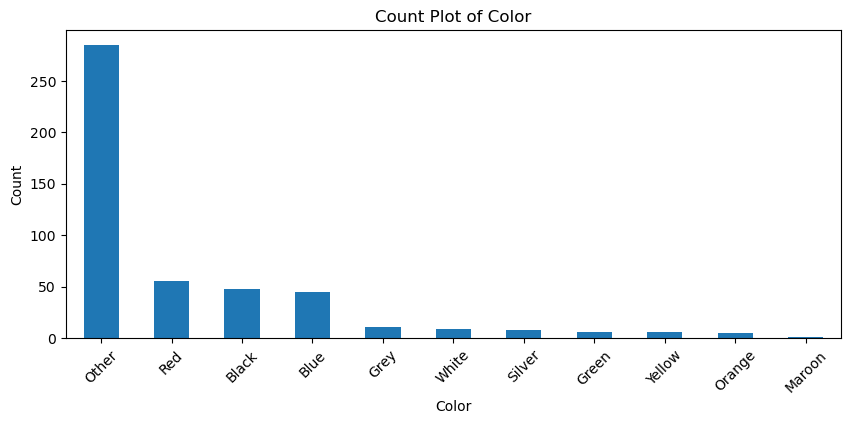

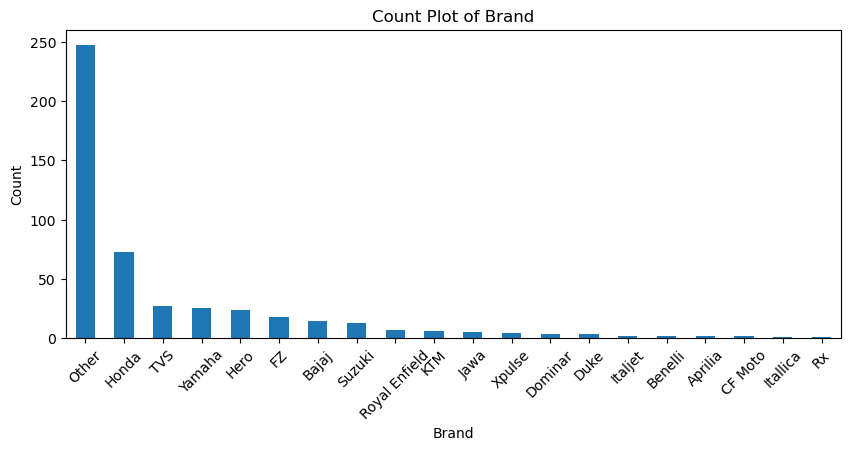

In [ ]:
cat_cols = ['Transmission','Types','Fuel','Color','Brand']

for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Bivariate Analysis

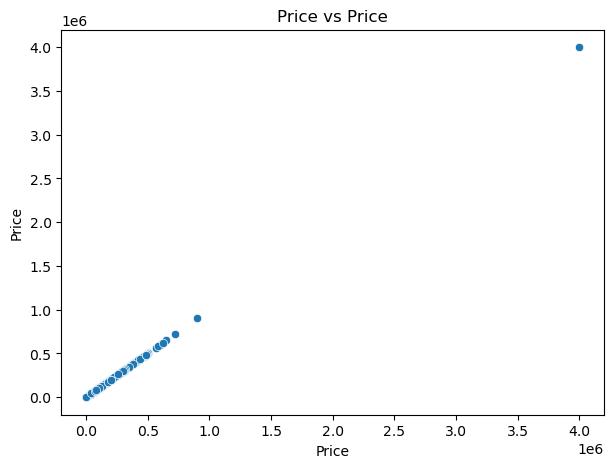

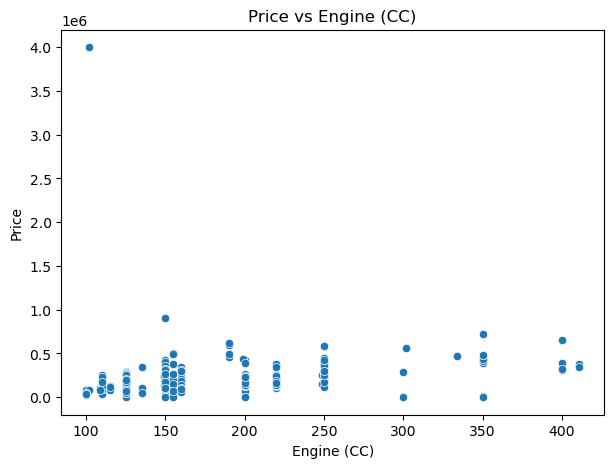

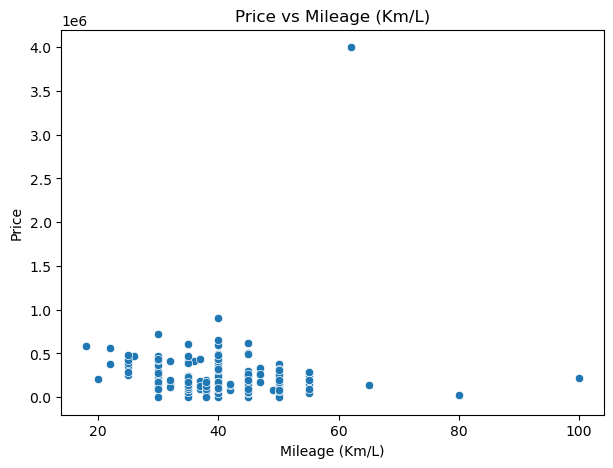

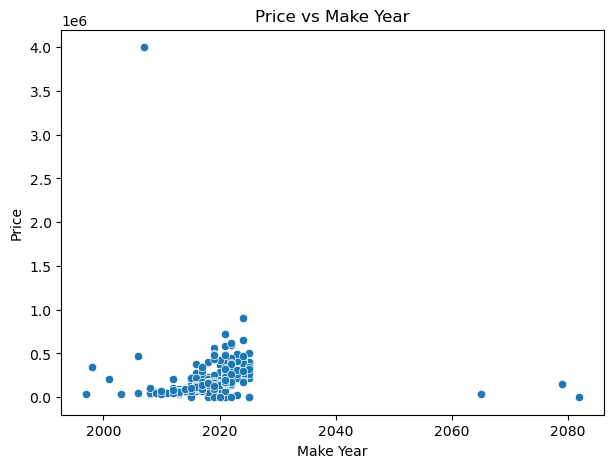

In [ ]:
# Price vs Numerical cols
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f"Price vs {col}")
    plt.show()

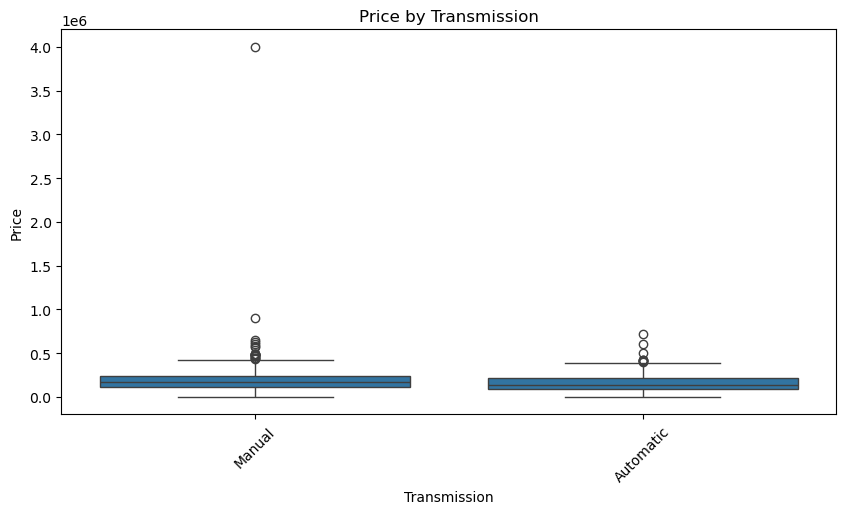

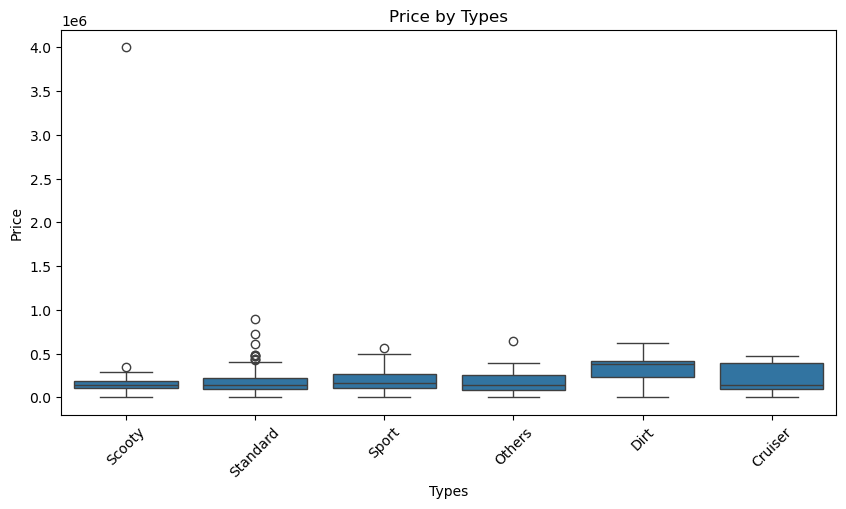

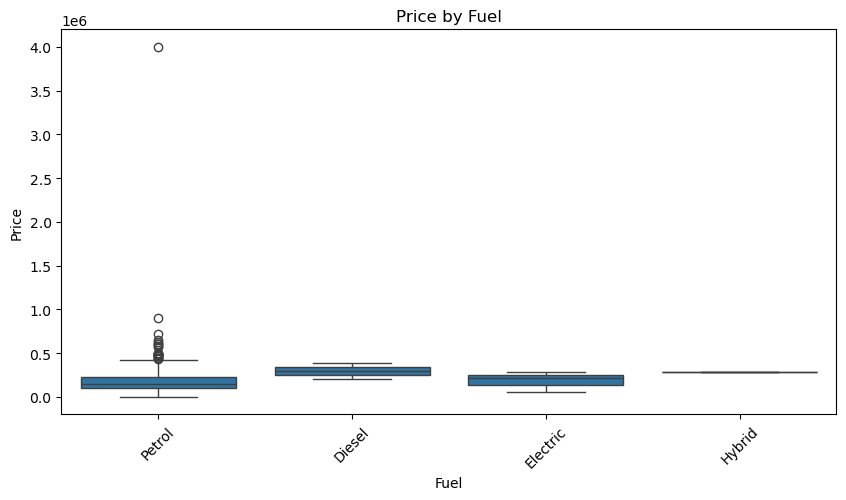

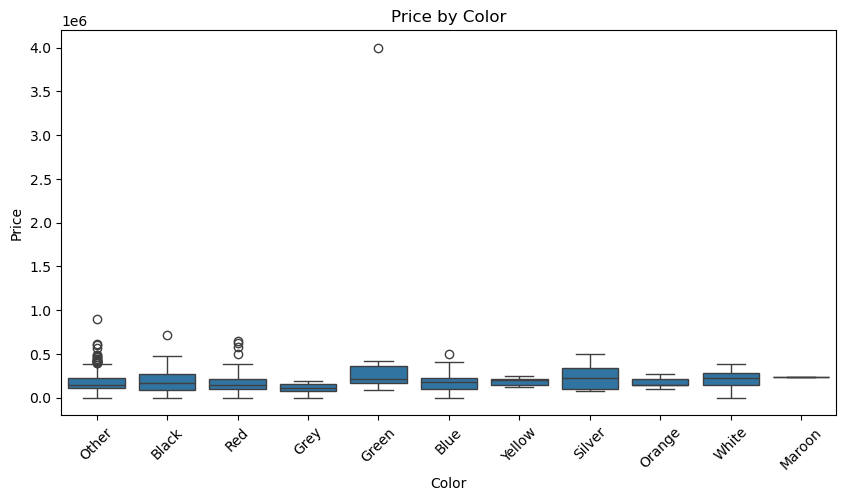

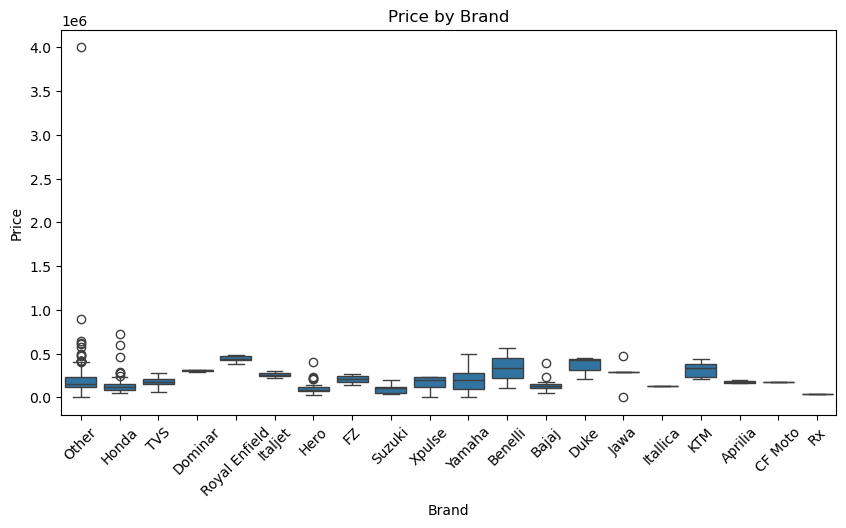

In [ ]:
# Price Vs Cat Features
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df['Price'])
    plt.title(f"Price by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [276]:
# Ensure seaborn theme
sns.set(style="whitegrid", palette="viridis")

# Show all plots inline
%matplotlib inline

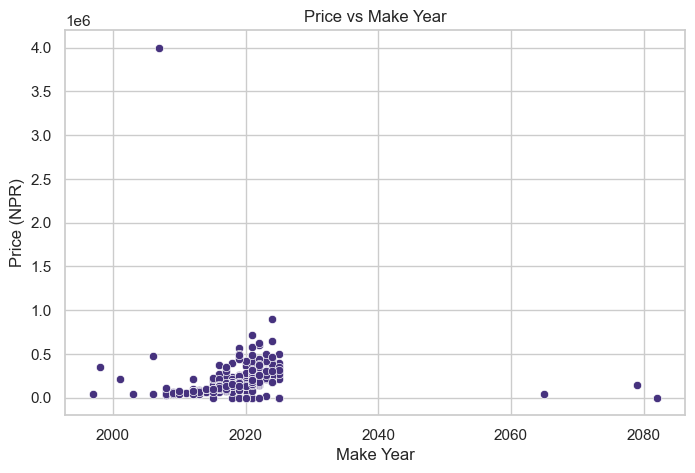

In [277]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Make Year", y="Price")
plt.title("Price vs Make Year")
plt.xlabel("Make Year")
plt.ylabel("Price (NPR)")
plt.show()

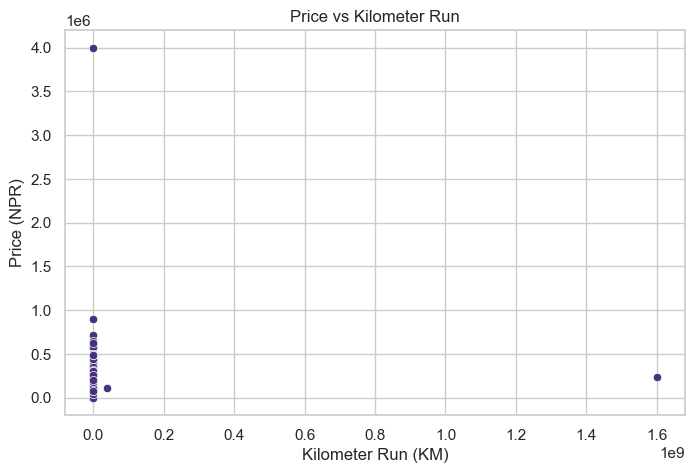

In [279]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Kilometer Run", y="Price")
plt.title("Price vs Kilometer Run")
plt.xlabel("Kilometer Run (KM)")
plt.ylabel("Price (NPR)")
plt.show()

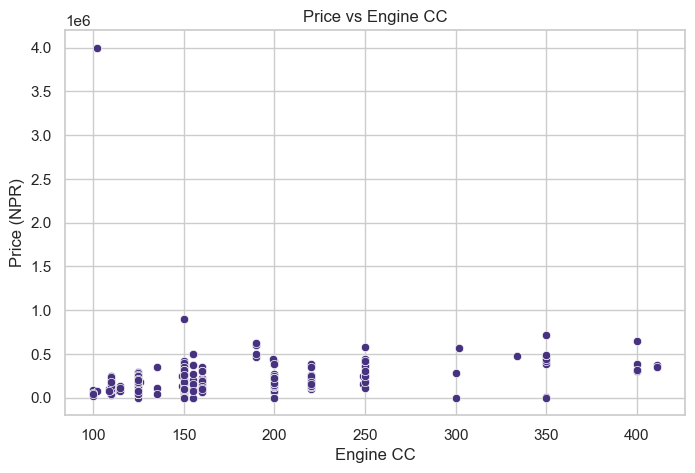

In [280]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Engine (CC)", y="Price")
plt.title("Price vs Engine CC")
plt.xlabel("Engine CC")
plt.ylabel("Price (NPR)")
plt.show()

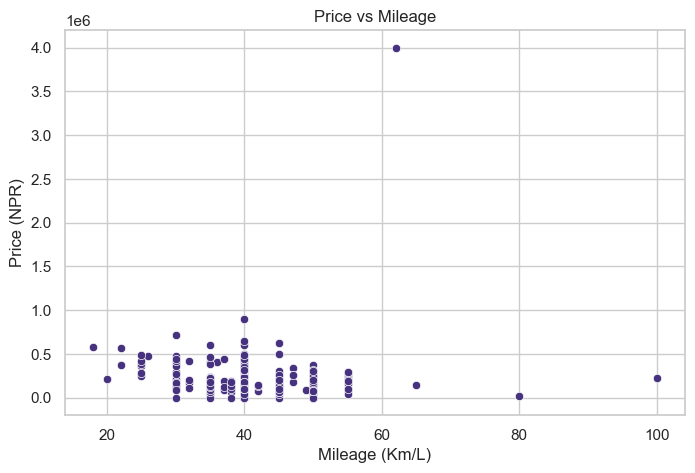

In [282]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Mileage (Km/L)", y="Price")
plt.title("Price vs Mileage")
plt.xlabel("Mileage (Km/L)")
plt.ylabel("Price (NPR)")
plt.show()

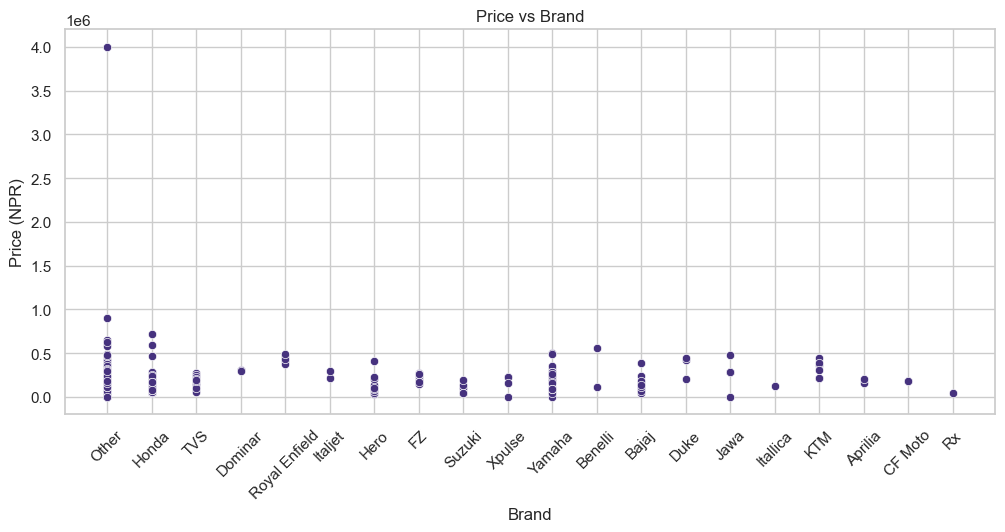

In [283]:
plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x="Brand", y="Price")
plt.title("Price vs Brand")
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Price (NPR)")
plt.show()

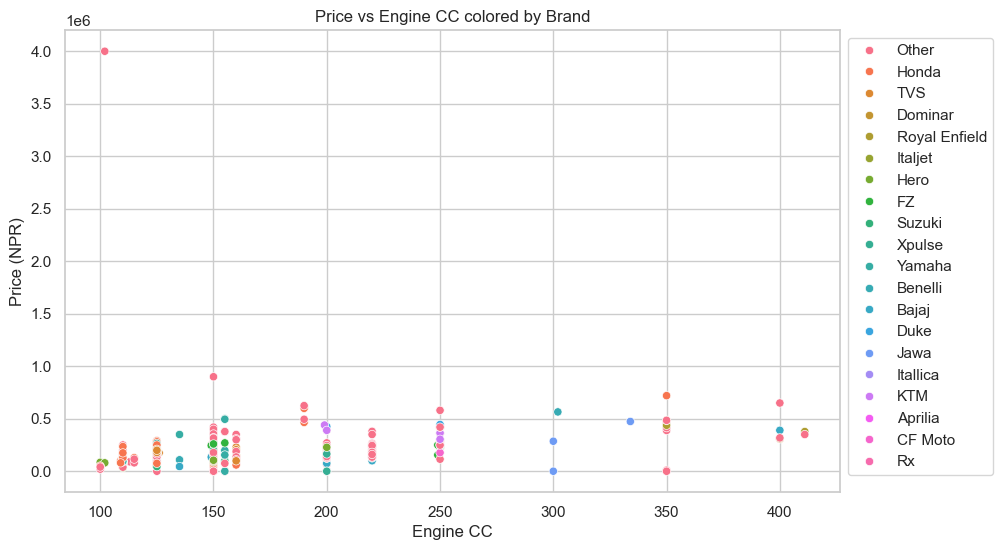

In [285]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Engine (CC)", y="Price", hue="Brand")
plt.title("Price vs Engine CC colored by Brand")
plt.xlabel("Engine CC")
plt.ylabel("Price (NPR)")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

## Multivariate Analysis

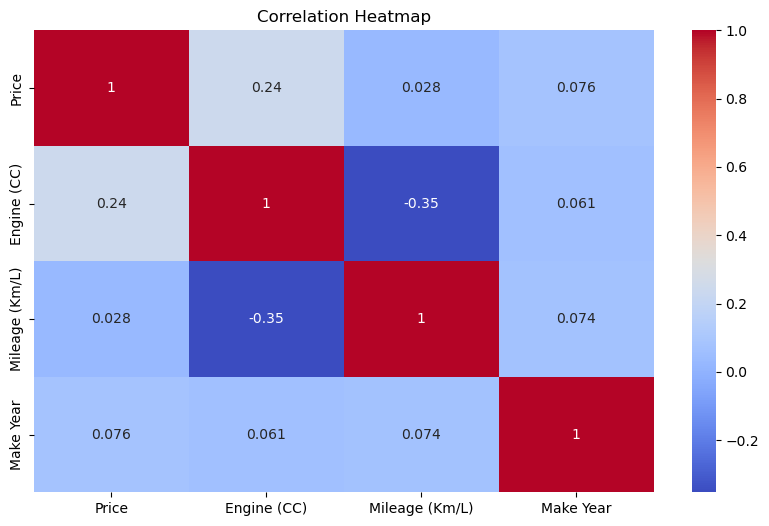

In [267]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

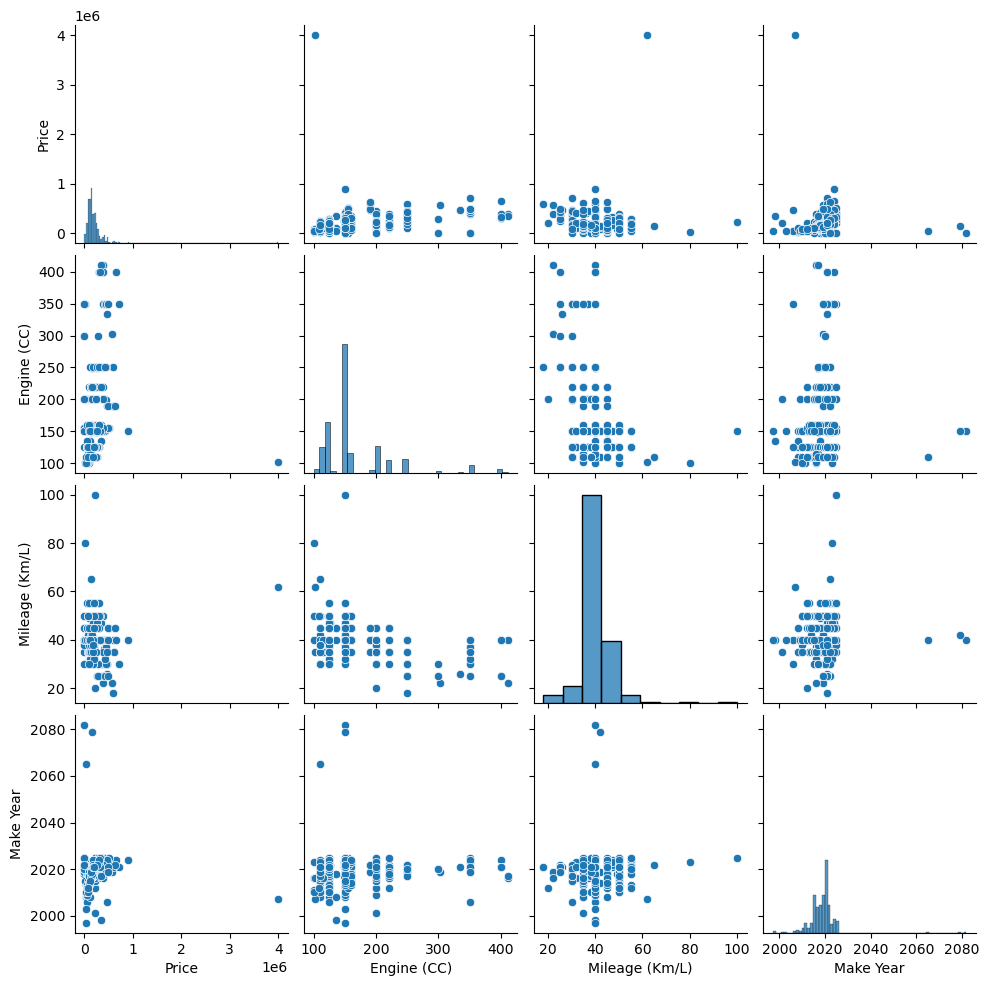

In [268]:
sns.pairplot(df[num_cols])
plt.show()

In [290]:
print(df.columns.tolist())

['Price', 'Transmission', 'Types', 'Fuel', 'Make Year', 'Lot No', 'Kilometer Run', 'Mileage (Km/L)', 'Engine (CC)', 'Color', 'Brand']


C:\Users\Hp\AppData\Local\Temp\ipykernel_6576\3619775020.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='magma')


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

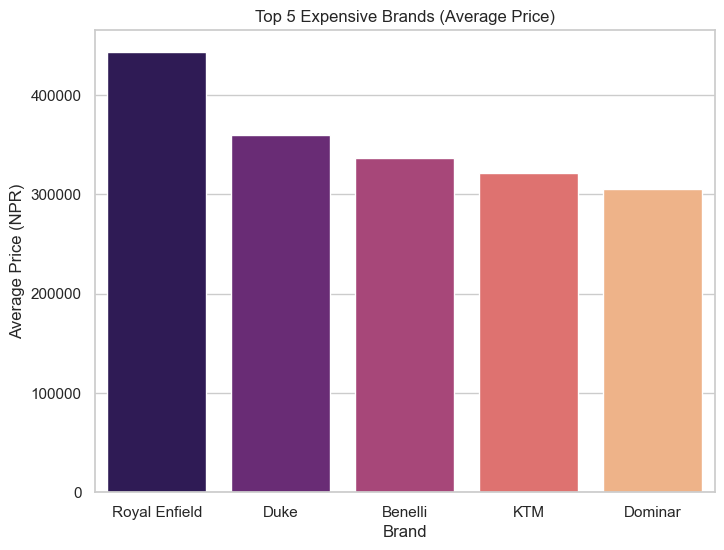

In [302]:
# Top expensive brands
top_brands = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='magma')
plt.title("Top 5 Expensive Brands (Average Price)")
plt.ylabel("Average Price (NPR)")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6576\392914586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_engines.index.astype(str), y=top_engines.values, palette='coolwarm')


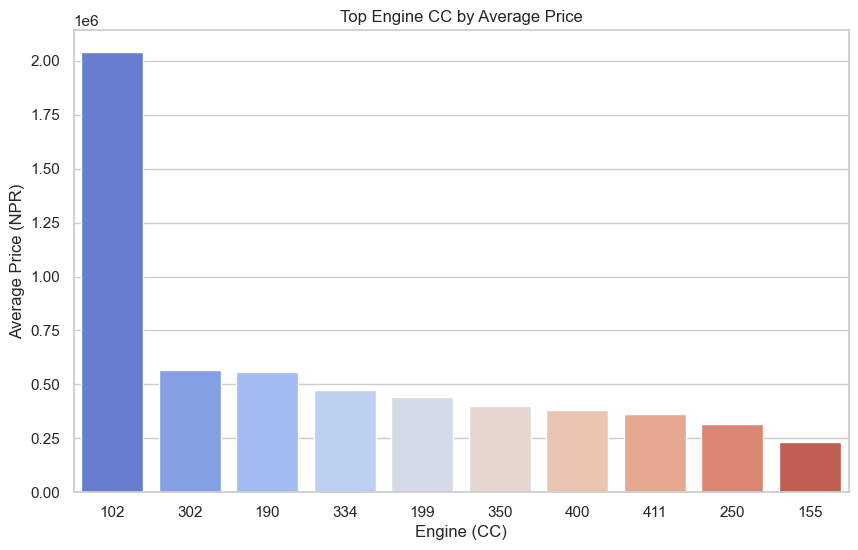

In [303]:
# Effect of Engine CC

top_engines = df.groupby('Engine (CC)')['Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_engines.index.astype(str), y=top_engines.values, palette='coolwarm')
plt.title("Top Engine CC by Average Price")
plt.xlabel("Engine (CC)")
plt.ylabel("Average Price (NPR)")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6576\1924672706.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trans_price.index, y=trans_price.values, palette='Set2')


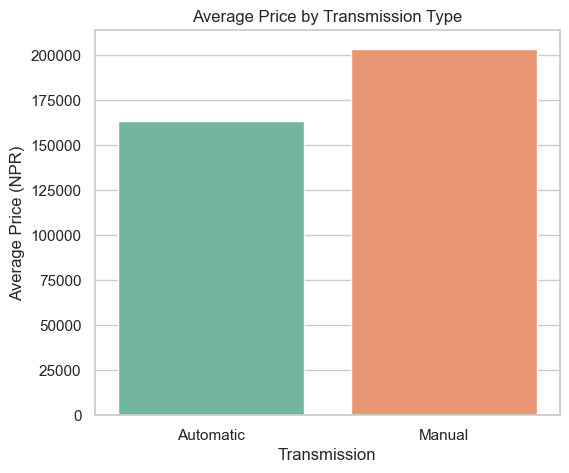

In [305]:
# Transmission types

trans_price = df.groupby('Transmission')['Price'].mean()
plt.figure(figsize=(6,5))
sns.barplot(x=trans_price.index, y=trans_price.values, palette='Set2')
plt.title("Average Price by Transmission Type")
plt.ylabel("Average Price (NPR)")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_6576\2474409586.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_price.index, y=type_price.values, palette='Set3')


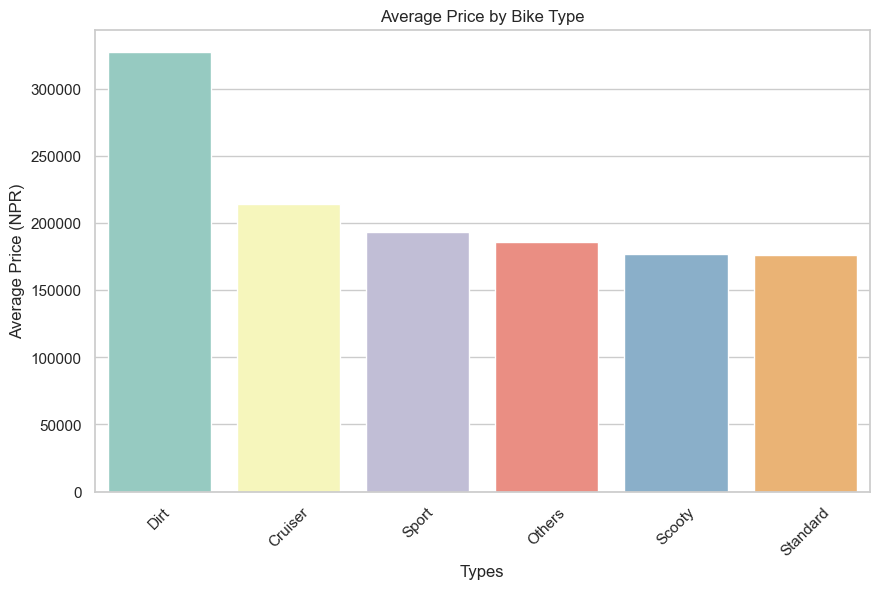

In [306]:
# Types (dirt bikes, scooters, sports...)

type_price = df.groupby('Types')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=type_price.index, y=type_price.values, palette='Set3')
plt.title("Average Price by Bike Type")
plt.ylabel("Average Price (NPR)")
plt.xticks(rotation=45)
plt.show()